In [32]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
!pip install huggingface_hub

In [19]:
BASE_DS_SAVE_PATH = '../data/squadv2/base_dataset.csv'
QA_DS_SAVE_PATH = '../data/squadv2/qa_dataset.csv'
CONTEXTS_SAVE_PATH = '../data/squadv2/contexts.csv'

In [2]:
splits = {'train': 'squad_v2/train-00000-of-00001.parquet', 'validation': 'squad_v2/validation-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/rajpurkar/squad_v2/" + splits["train"])

In [16]:
df.to_csv(BASE_DS_SAVE_PATH, index=False)

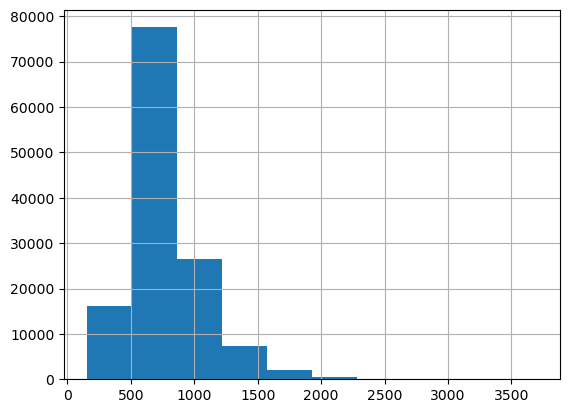

In [10]:
plt.hist(list(map(len, df['context'].tolist())))
plt.grid()
plt.show()

In [17]:
# question duplication
print(len(df['question'].unique()), len(df['question']))

130217 130319


In [18]:
# context duplication
print(len(df['context'].unique()), len(df['context']))

19029 130319


In [22]:
filtered_df = df.drop_duplicates(subset=['question']).reset_index(drop=True)

In [23]:
filtered_df.shape

(130217, 5)

In [28]:
contexts_dataset = df['context'].unique().tolist()
print(len(contexts_dataset))

19029


In [37]:
qa_dataset = []

for i in tqdm(range(df.shape[0])):
    if len(df['answers'][i]['text']):
        item = [ df['question'][i], df['answers'][i]['text'][0], contexts_dataset.index(df['context'][i]), {'base_id': df['id'][i]}]
        qa_dataset.append(item)

print(filtered_df.shape, len(qa_dataset))

100%|██████████| 130319/130319 [00:11<00:00, 11790.88it/s]

(130217, 5) 86821


In [38]:
contexts_df = pd.DataFrame(contexts_dataset, columns=['context'])
print(contexts_df.shape)

(19029, 1)


In [39]:
qa_df = pd.DataFrame(qa_dataset, columns=['question', 'answer', 'relevant_context_id', 'metadata'])
print(qa_df.shape)

(86821, 4)


In [41]:
qa_df.to_csv(QA_DS_SAVE_PATH, index=False)

In [42]:
contexts_df.to_csv(CONTEXTS_SAVE_PATH, index=False)